In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D
from scdepth.bindings import Downsampler
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import scdepth.fn as fn, scdepth.fit as fit, scdepth.pl as pl, scdepth.filt as filt
from scipy import stats
import os
import subprocess

In [2]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
adf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')

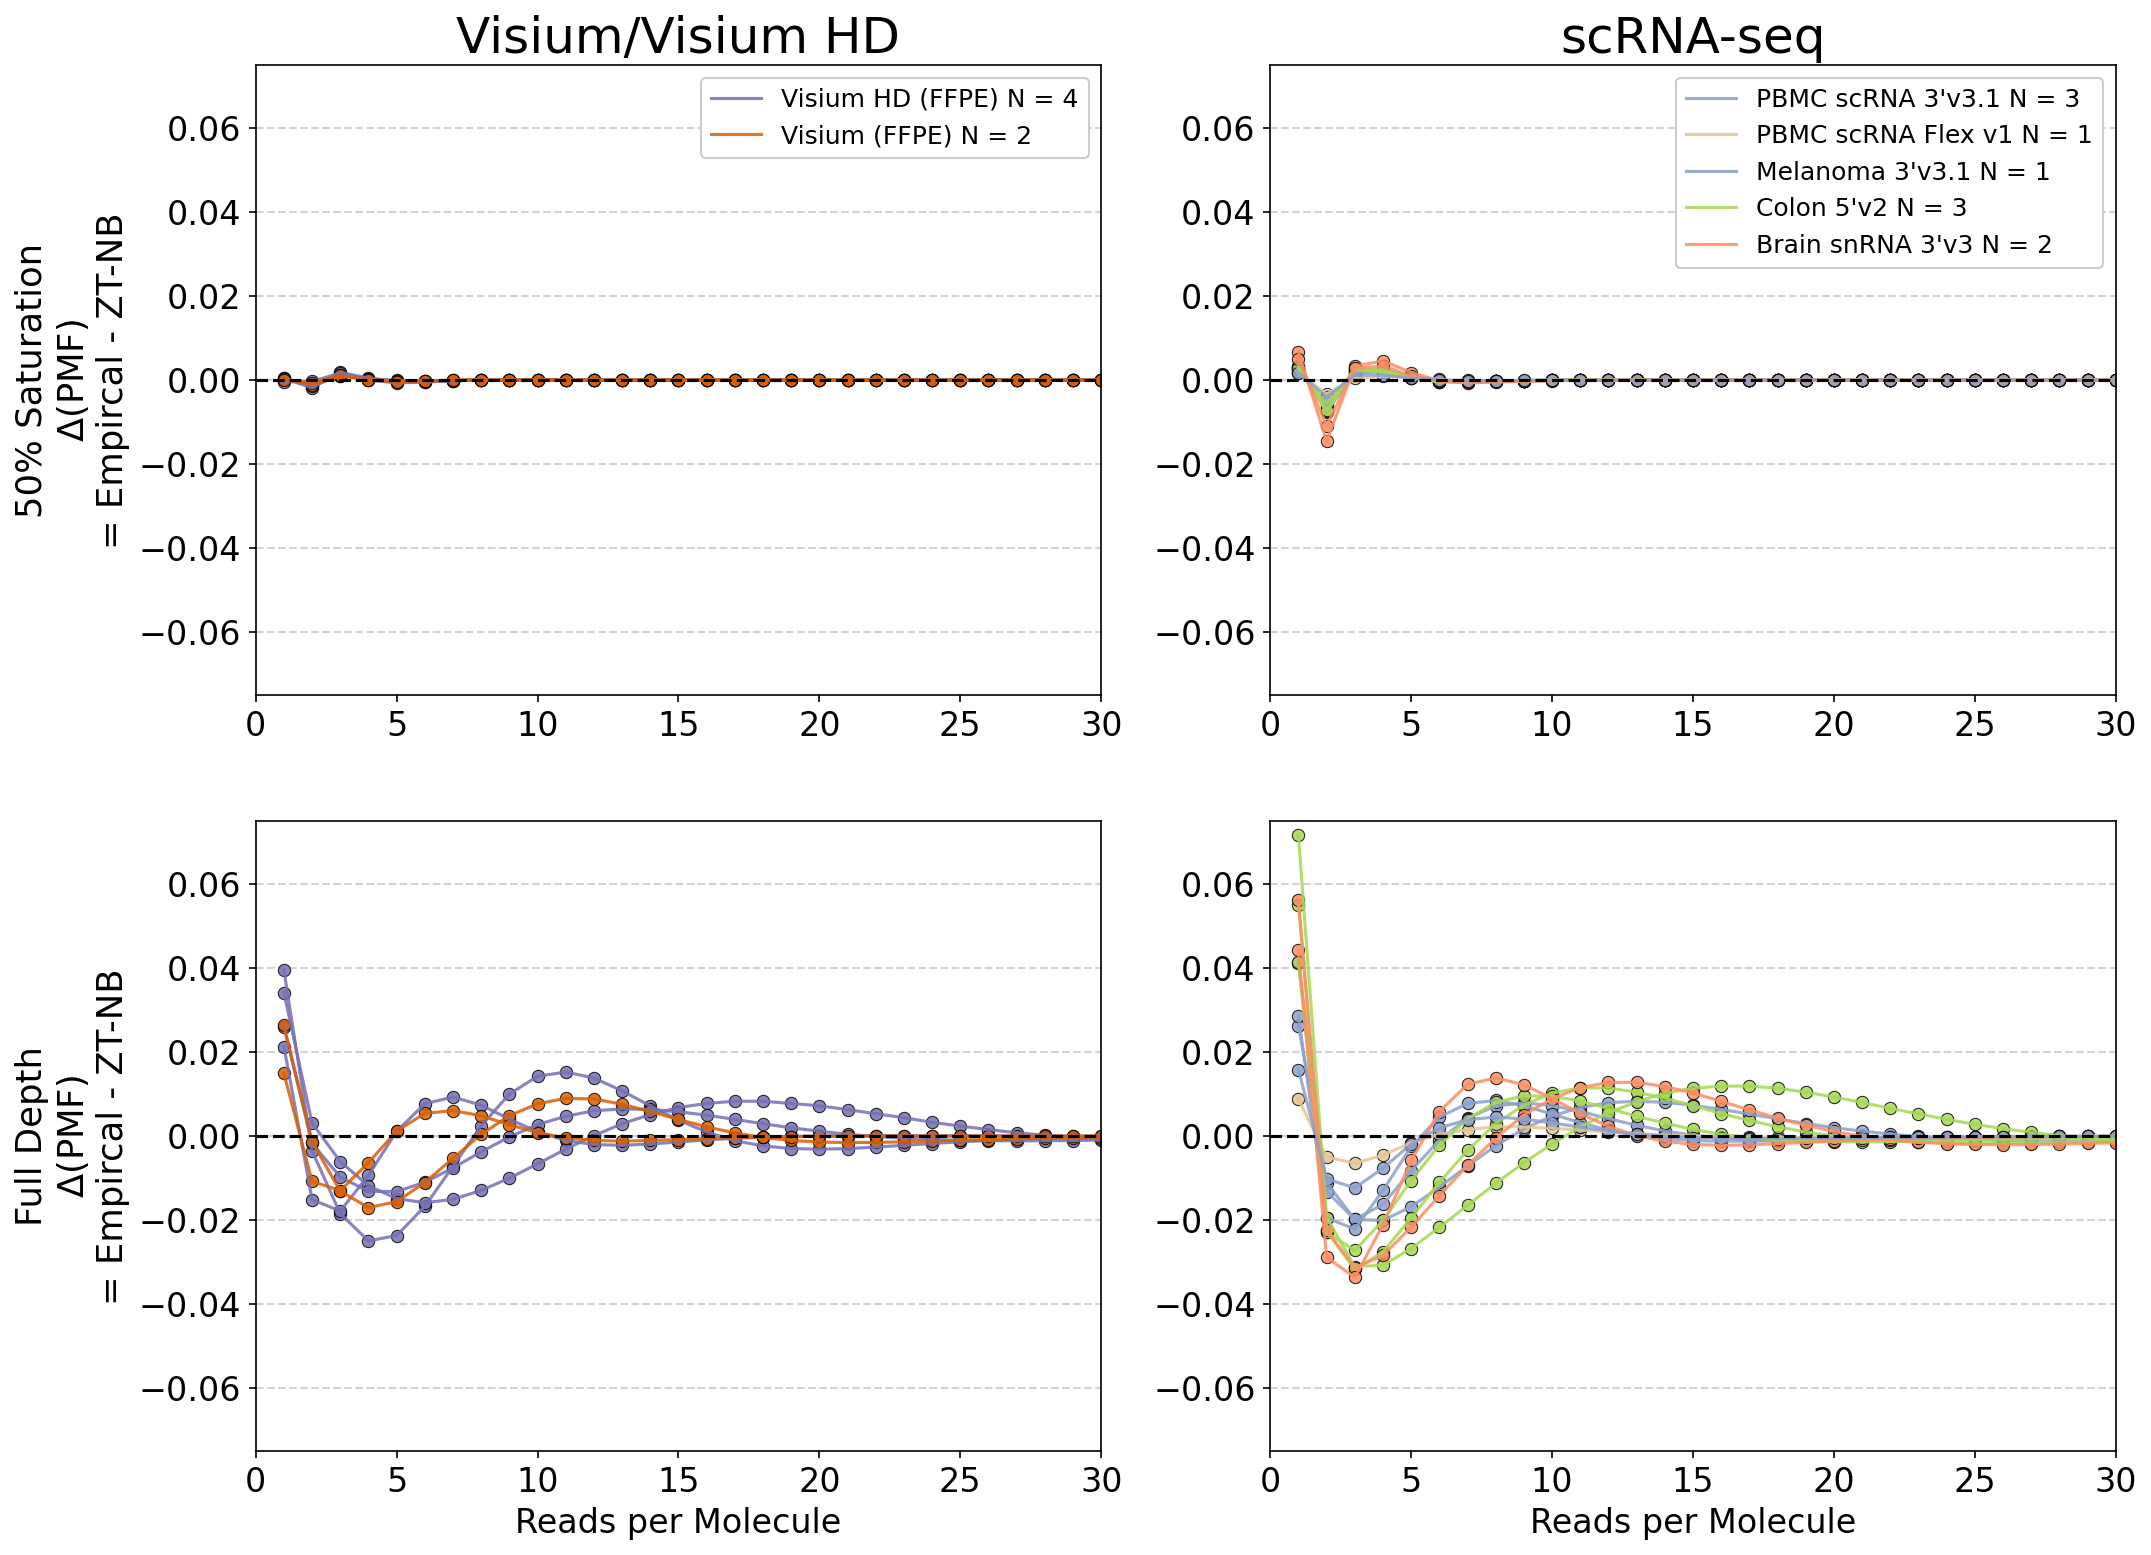

In [3]:
from scdepth.ztnb2 import ztnb_component_contributions
from collections import Counter
fig, axs = pl.figax(2, 2, w=8, h=6)
cc = Counter()
seen = set()
data = []
for _, c in adf.iterrows():
    f1 = f'../{c["dataset"]}/{c["sample"]}/scdepth_fit_baseline.txt'
    f2 = f'../{c["dataset"]}/{c["sample"]}/scdepth_fit_rpm_histograms.txt'
    if not  os.path.isfile(f1):
        continue
    bdf = pd.read_csv(f1, sep='\t').iloc[0]

    if bdf.full_saturation < 80.0:
        continue
    cc[c.title] += 1
    rdf = pd.read_csv(f2, sep='\t')

    data.append((c, bdf, rdf))



for c, ldf, rdf in data:
    rx = axs[:,0] if 'visium' in c.library_prep else axs[:,1]
    hists = [rdf['total'].to_numpy(float), rdf['full_total'].to_numpy(float)]
    hreads = ldf['reads'], ldf['full_reads']
    bins = rdf['bin'].to_numpy(int)
    for ax, rpm, reads in zip(rx, hists, hreads):
        ff = fit.NBLibFit()
        ff.fit(rpm, reads=reads, molecules=0)
        pmf = rpm/rpm.sum()
        #cmf = np.cumsum(pmf)
        pred_pmf = ff.predict_pmf(len(bins))
        cmf = pmf
        pred_cdf = pred_pmf
        #pred_cdf = np.cumsum(pred_pmf)
        lab = '_'
        if c.title not in seen:
            lab = f'{c.title} N = {cc[c.title]}'
            seen.add(c.title)
            
        ax.plot(bins, cmf - pred_cdf, color=c.color, alpha=0.85, label=lab, lw=1.5)
        ax.scatter(bins, cmf - pred_cdf, marker='o', s=35, edgecolor='k', lw=0.5, alpha=0.85, color=c.color)
for ax in axs.flatten():
    ax.set_xlim(0, 30)
    ax.axhline(0.0, ls='--', color='black', lw=1.5)
    ax.set_ylim(-0.075, 0.075)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid(axis='y', color='lightgray', ls='--', lw=1, which='both')
    ax.set_axisbelow(True)


axs[0,0].set_ylabel('50% Saturation\n$\Delta{(\\mathrm{PMF})}$\n= Empircal - ZT-NB', fontsize=17)
axs[1,0].set_ylabel('Full Depth\n$\Delta{(\\mathrm{PMF})}$\n= Empircal - ZT-NB', fontsize=17)
for ax in axs[1]:
    ax.set_xlabel('Reads per Molecule', fontsize=16)

for ax in axs[0]:
    ax.legend(loc = 'upper right', framealpha=1, fontsize=12)

axs[0,0].set_title('Visium/Visium HD', fontsize=24)
axs[0,1].set_title('scRNA-seq', fontsize=24)
fig.savefig('../Figures/Figure S2 ZT-NB CMF.svg', bbox_inches='tight')
